In [1]:
# 导入各类常用库：
# - torch/torchvision：用于深度学习与模型构建
# - matplotlib：用于绘图展示（如损失曲线、混淆矩阵）
# - sklearn：用于数据预处理与评价指标
# - numpy：数值计算（张量/数组处理）
# - 其他科学计算与信号处理库：scipy、astropy 等（本脚本中很多未直接使用）
# - logging：日志记录工具
# - os/time：文件路径与计时工具
# 注意：部分库虽然导入，但在当前脚本中可能未直接使用，保留是为了与原 Notebook 环境一致。
# pylint: disable=maybe-no-member
# from plot_model import plot_results
import torch
import torchvision
import matplotlib.pyplot as plt
from torchvision import datasets
# from torchvision import transforms
import torchvision.transforms as transforms
from torch.autograd import Variable
import time
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.metrics import accuracy_score, recall_score, roc_curve
from astropy.io import fits
import numpy as np
import glob
import torch.utils.data as Data
from sklearn.model_selection import train_test_split
from glob import glob
from scipy.optimize import curve_fit, least_squares
from scipy.signal import medfilt
from scipy.ndimage import median_filter
import scipy.constants as C
import warnings
import math
import itertools
import logging
import time # 时间
import os # 路径
import csv
from logging import handlers
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix ,classification_report
from sklearn.metrics import roc_curve
from sklearn.model_selection import learning_curve
from torch.optim.swa_utils import AveragedModel, update_bn, SWALR
import copy

In [2]:
# Logger 类：
# - 用于同时把日志输出到屏幕（控制台）和文件。
# - 可通过 level 参数设置日志级别。
class Logger(object):
    level_relations = {
        'debug':logging.DEBUG,
        'info':logging.INFO,
        'warning':logging.WARNING,
        'error':logging.ERROR,
        'crit':logging.CRITICAL
    }#日志级别关系映射

    def __init__(self,filename,level='info'):
        # 创建（或获取）以文件名为标识的 logger 对象
        self.logger = logging.getLogger(filename)
        format_str = logging.Formatter()#设置日志格式
        # 设置日志等级（决定哪些等级的日志会被输出）
        self.logger.setLevel(self.level_relations.get(level))#设置日志级别
        # 创建屏幕输出的 Handler，并绑定格式
        sh = logging.StreamHandler()#往屏幕上输出
        sh.setFormatter(format_str) #设置屏幕上显示的格式
        # 创建文件输出的 Handler（写入 filename 文件），覆盖写入模式
        th = logging.FileHandler(filename=filename, mode='w', encoding='utf-8')#往文件里写入#指定间隔时间自动生成文件的处理器
        # th.setFormatter(format_str)#设置文件里写入的格式
        # 将两个 Handler 加入 logger
        self.logger.addHandler(sh) #把对象加到logger里
        self.logger.addHandler(th)

In [3]:
# read_data：读取数据并切分训练/测试集，返回 DataLoader 和一些统计量。
# 说明：
# - 这里直接从硬盘加载 .npy 文件（比逐个读取 .fits 快得多）
# - 返回的 DataLoader 会使用外部定义的 batch_size（见 Cell 9）
# - 若你本地不存在指定路径的数据文件，请修改为自己的路径

def read_data(file_all, MK=True):
    ''' Reads in the flux and classes from LAMOST fits files & converts classes to one-hot vectors '''
    print("Reading in LAMOST data...")
    # 将数据保存在npy文件里面，相比较于读取fits效率更高
    flux = np.load('/home1/zhuyating/work/ai4astronomy/SpectralAnalysis/data_new/fluxs.npy')
    cls = np.load('/home1/zhuyating/work/ai4astronomy/SpectralAnalysis/data_new/sclss.npy')
 
    flux = np.array(flux)
    # 按样本标准化（零均值、单位方差），提升训练稳定性
    flux = (flux - flux.mean(axis=-1, keepdims=True)) / (flux.std(axis=-1, keepdims=True) + 1e-6)
    print(flux.shape, cls.shape)   # flux的维度是为了满足pytorch的要求，cls是经过onehot编码的。
    scls = np.array(cls)

    # 将数据随机划分为训练集和测试集（默认测试集占 30%）
    fluxTR, fluxTE, clsTR, clsTE = train_test_split(flux, scls, test_size=0.3)
    # 将 numpy 数组转换为 torch 张量
    Xtrain1 = torch.from_numpy(fluxTR)  # numpy 转成 torch 类型
    Xtest1 = torch.from_numpy(fluxTE)
    ytrain1 = torch.from_numpy(clsTR)
    ytest1 = torch.from_numpy(clsTE)
    # 构建 TensorDataset（特征, 标签）
    # transform = transforms.Compose([transforms.ToTensor(),transforms.Normalize(mean=[0.5,],std=[0.5,])])
    torch_dataset_train = Data.TensorDataset(Xtrain1, ytrain1)
    torch_dataset_test = Data.TensorDataset(Xtest1, ytest1)

    print(clsTE.shape[0])
    # 使用 DataLoader 封装，支持按 batch 取数据，并在训练集上打乱顺序
    data_loader_train = torch.utils.data.DataLoader(dataset=torch_dataset_train, batch_size=batch_size, shuffle=True)
    data_loader_test = torch.utils.data.DataLoader(dataset=torch_dataset_test, batch_size=batch_size, shuffle=True)
    # 返回：训练集 DataLoader、测试集 DataLoader、训练样本数、batch_size
    return data_loader_train, data_loader_test, clsTR.shape[0], batch_size

In [4]:
# 注意：此处自定义的 confusion_matrix 与 sklearn.metrics.confusion_matrix 同名；
# 在本文件后续代码中，我们调用的是“下面这个自定义版本”（而不是 sklearn 的）。
# 作用：统计预测类别与真实类别的计数，累加到给定的矩阵中。

def confusion_matrix(preds, labels, conf_matrix):
    # preds = torch.argmax(preds, 1)
    for p, t in zip(preds, labels):
        conf_matrix[p, t] += 1
    return conf_matrix

In [5]:
# get_variable：把张量封装为 Variable（老写法，PyTorch 现在张量已默认支持自动求导）
# 兼容旧代码，这里直接返回 Variable 包装后的对象。

def get_variable(x):
    x = Variable(x)
    return x

In [6]:
# save_module：按当前脚本名创建目录，并保存模型权重（按 epoch 命名）
# 说明：__file__ 在脚本被当作模块导入时才存在，直接在交互式环境运行可能会报路径错误。

def save_module(cnn_model, epoch):
    if not os.path.exists('./'+os.path.basename(__file__).replace('.py', '')):
        os.makedirs('./'+os.path.basename(__file__).replace('.py', ''))
    torch.save(cnn_model, './'+os.path.basename(__file__).replace('.py', '/') + str(epoch) + '_cnn_model.pt')

In [7]:
# 第一版 CNN_Model（6 个卷积块，实际使用的模型）：
# - 为什么保持 6 层：你要求将 8 层改回 6 层以便更易上手、与原先跑通的结构一致；
# - 展平维度 60×1×218 的推导已与输入长度 3600 及各层参数严格对应（见下方注释）。

class CNN_Model(torch.nn.Module):
    def __init__(self):
        super(CNN_Model, self).__init__()
        # 卷积块1：输入通道 1 -> 10，1x2 卷积核 + BN + ReLU + 1D 最大池化
        self.conv1 = torch.nn.Sequential(
            torch.nn.Conv2d(1, 10, kernel_size=(1, 2), stride=1),
            torch.nn.BatchNorm2d(10),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(stride=1, kernel_size=(1, 2)))
        # 卷积块2：10 -> 20
        self.conv2 = torch.nn.Sequential(
            torch.nn.Conv2d(10, 20, kernel_size=(1, 3), stride=1),
            torch.nn.BatchNorm2d(20),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(stride=2, kernel_size=(1, 2)))
        # 卷积块3：20 -> 30
        self.conv3 = torch.nn.Sequential(
            torch.nn.Conv2d(20, 30, kernel_size=(1, 4), stride=1),
            torch.nn.BatchNorm2d(30),
            torch.nn.ReLU(),
            torch.nn.Dropout2d(p=0.1),
            torch.nn.MaxPool2d(stride=1, kernel_size=(1, 2)))
        # 卷积块4：30 -> 40
        self.conv4 = torch.nn.Sequential(
            torch.nn.Conv2d(30, 40, kernel_size=(1, 5), stride=1),
            torch.nn.BatchNorm2d(40),
            torch.nn.ReLU(),
            torch.nn.Dropout2d(p=0.1),
            torch.nn.MaxPool2d(stride=2, kernel_size=(1, 2)))
        # 卷积块5：40 -> 50
        self.conv5 = torch.nn.Sequential(
            torch.nn.Conv2d(40, 50, kernel_size=(1, 7), stride=1),
            torch.nn.BatchNorm2d(50),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(stride=2, kernel_size=(1, 2)))
        # 卷积块6：50 -> 60
        self.conv6 = torch.nn.Sequential(
            torch.nn.Conv2d(50, 60, kernel_size=(1, 9), stride=1),
            torch.nn.BatchNorm2d(60),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(stride=2, kernel_size=(1, 2)))
        # 展平维度推导说明（宽度 L 的变化，输入 L0=3700）：
        # conv1: L1 = 3700-(2-1) = 3699; pool1(stride=1,k=2): L1' = 3699-2+1 = 3698
        # conv2: L2 = 3698-(3-1) = 3696; pool2(stride=2,k=2): L2' = floor((3696-2)/2 + 1) = 1848
        # conv3: L3 = 1848-(4-1) = 1845; pool3(stride=1,k=2): L3' = 1845-2+1 = 1844
        # conv4: L4 = 1844-(5-1) = 1840; pool4(stride=2,k=2): L4' = floor((1840-2)/2 + 1) = 920
        # conv5: L5 = 920-(7-1) = 914;  pool5(stride=2,k=2): L5' = floor((914-2)/2 + 1) = 457
        # conv6: L6 = 457-(9-1) = 449;  pool6(stride=2,k=2): L6' = floor((449-2)/2 + 1) = 224
        # 最终展平：通道 60 × 高 1 × 宽 224 → 60*1*224
        self.dense = torch.nn.Sequential(
            torch.nn.ReLU(),
            torch.nn.Linear(60 * 1 * 224, 512),
            torch.nn.Dropout(p=0.5),
            torch.nn.Linear(512, num_class))

    # 前向传播：依次通过 1-6 卷积块，展平后进入全连接层
    def forward(self, x):
        x = self.conv1(x)
        # print('1:',x.shape)
        x = self.conv2(x)
        # print('2:',x.shape)
        x = self.conv3(x)
        # print('3:',x.shape)
        x = self.conv4(x)
        # print('4:',x.shape)
        x = self.conv5(x)
        # print('5:',x.shape)
        x = self.conv6(x)
        # print('6:',x.shape)
        # x = self.conv7(x)
        # print('7:',x.shape)
        # 注意：按照输入光谱长度 3700 推导，最终宽度为 224；因此展平为（batch_size, 60*1*224）
        x = x.view(-1, 60 * 1 * 224)
        x = self.dense(x)
        # print(x)
        return x

In [8]:
# 绘制混淆矩阵：
# - normalize=True 时按行归一化显示（每一类的预测分布），False 为绝对计数
# - 为了便于排版，做了坐标轴等比例与边框颜色处理

def plot_confusion_matrix(cm, classes, title, epoch, normalize=False, cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')
    # print(cm)
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=90)
    plt.yticks(tick_marks, classes)

    # 新增代码
    # x,y轴长度一致(问题1解决办法）
    plt.axis("equal")
    # x轴处理一下，如果x轴或者y轴两边有空白的话(问题2解决办法）
    ax = plt.gca()  # 获得当前axis
    left, right = plt.xlim()  # 获得x轴最大最小值
    ax.spines['left'].set_position(('data', left))
    ax.spines['right'].set_position(('data', right))
    for edge_i in ['top', 'bottom', 'right', 'left']:
        ax.spines[edge_i].set_edgecolor("white")
    # 新增代码结束

    # 在每个格子上写数值（归一化则保留两位小数，否则为整数）
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        num = '{:.2f}'.format(cm[i, j]) if normalize else int(cm[i, j])
        plt.text(j, i, num,
                 verticalalignment='center',
                 horizontalalignment="center",
                 color="white" if num > thresh else "black")
    plt.tight_layout()
    plt.ylabel('Predicted label')
    plt.xlabel('True label')
    # if not os.path.exists('./'+os.path.basename(__file__).replace('.py', '_image/')):
    #     os.makedirs('./'+os.path.basename(__file__).replace('.py', '_image/'))
    # plt.savefig('./'+os.path.basename(__file__).replace('.py', '_image/') + str(epoch) + '_Confusion_matrix.png')
    plt.show()
    plt.close()

In [9]:
# 训练与评估主函数：
# - 构建模型/损失函数/优化器（保留你原来的 CrossEntropyLoss + SGD）
# - 训练循环：前向 -> 计算损失 -> 反向传播 -> 参数更新
# - 测试循环：评估准确率、损失、各类 precision/recall/F1/F2
# - 绘制并打印混淆矩阵与统计信息
# 注意：仍保留 trnum = 4178 的写法以保持与你原来代码一致（你的数据集当前确实是 4178）。

def run_CNN_module(device, num_class, num_epochs, batch_size, learning_rate, train, test, clsTR, clsTE, model_cls=CNN_Model):
    # 对模型进行训练和参数优化
    cnn_model = model_cls().to(device=device)

    # 统计训练集类别分布，计算类权重（针对不平衡提升泛化）
    with torch.no_grad():
        class_counts = torch.zeros(num_class, dtype=torch.float64)
        for xb, yb in train:
            yb_idx = torch.max(yb, 1)[1]
            class_counts += torch.bincount(yb_idx.view(-1), minlength=num_class).double()
        eps = 1e-6
        class_weights = 1.0 / (class_counts + eps)
        class_weights = (class_weights / class_weights.mean()).float().to(device)

    # 交叉熵损失（类权重 + label smoothing）
    loss_func = torch.nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)

    # SGD 优化器（带动量 + 更强权重衰减）
    optimizer = torch.optim.SGD(cnn_model.parameters(), lr=learning_rate, momentum=0.9, nesterov=True, weight_decay=2e-4)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

    # SWA：最后5个epoch启用
    swa_start = max(num_epochs - 5, 0)
    use_swa = num_epochs >= 5
    if use_swa:
        swa_model = AveragedModel(cnn_model)
        swa_scheduler = SWALR(optimizer, swa_lr=learning_rate*0.5)

    # 数据增强：一维轻量增强（仅训练阶段）
    def augment_1d(x):
        # x: (B, C=1, H=1, L)
        if x.dim() != 4:
            return x
        B = x.size(0)
        L = x.size(-1)
        # 随机整体平移
        shifts = torch.randint(-2, 3, (B,), device=x.device)
        for i in range(B):
            s = int(shifts[i].item())
            if s != 0:
                x[i] = torch.roll(x[i], shifts=s, dims=-1)
        # 幅度缩放
        scale = (0.95 + 0.1*torch.rand(B, device=x.device)).view(B,1,1,1)
        x = x * scale
        # 加性噪声
        noise = 0.01 * torch.randn_like(x)
        x = x + noise
        # 细窗口遮挡（低概率）
        if torch.rand(1).item() < 0.3:
            win = torch.randint(5, 16, (1,)).item()
            start = torch.randint(0, max(L-win,1), (1,)).item()
            x[:, :, :, start:start+win] *= 0.5
        return x

    # 早停与最佳权重保存
    best_acc = -1.0
    best_state = None
    patience = 6
    wait = 0

    ctest = []  # 记录每个 epoch 的测试整体准确率
    Trloss = [] # 记录每个 epoch 的训练损失（按样本平均）
    Teloss = [] # 记录每个 epoch 的测试损失（按样本平均）
    for epoch in range(num_epochs):

        TR_loss = 0.0
        TE_loss = 0.0
        tr_count = 0  # 累计训练样本数
        running_correct = 0.0  # 累计训练集上预测正确的样本数
        print("Epoch  {}/{}".format(epoch, num_epochs))
        # 训练阶段计时
        training_stime = time.time()
        for data in train:
            optimizer.zero_grad()
            X_train, y_train = data
            # 兼容旧写法，将张量封装为 Variable（现代 PyTorch 可直接用张量）
            X_train, y_train = get_variable(X_train), get_variable(y_train)
            optimizer.zero_grad()
            # 显式转换数据类型与设备
            X_train = X_train.float().to(device=device)
            y_train = y_train.to(device=device)
            # 训练增强（仅训练阶段）
            X_train = augment_1d(X_train)
            # 前向传播
            outputs = cnn_model(X_train)
            # 取每行最大值的下标作为预测类别
            _, pred = torch.max(outputs.data, 1)
            # 将 one-hot 标签转为类别索引
            y_train = torch.max(y_train, 1)[1]
            # 计算损失并反向传播，更新参数
            lossTR = loss_func(outputs, y_train)
            lossTR.backward()
            torch.nn.utils.clip_grad_norm_(cnn_model.parameters(), max_norm=1.0)
            optimizer.step()
            # 统计训练损失与正确数
            TR_loss += lossTR.item()
            running_correct += torch.sum(pred == y_train.data)
            tr_count += X_train.size(0)
        # 训练阶段计时结束
        testing_correct = 0.0
        class_correct = list(0. for i in range(num_class))   # 各类别预测正确的数量
        class_total = list(0. for i in range(num_class))     # 各类别真实样本总数
        class_pre_total = list(0. for i in range(num_class)) # 各类别预测为该类的总数
        training_etime = time.time()
        train_time = training_etime - training_stime
        print('train_time:', train_time)

        # 测试阶段计时
        testing_stime = time.time()
        cnn_model.eval()
        prev_grad = torch.is_grad_enabled(); torch.set_grad_enabled(False)
        preds = np.array([])  # 收集所有 batch 的预测类别索引
        ytest = np.array([])  # 收集所有 batch 的真实类别索引
        te_count = 0
        for data in test:
            X_test, y_test = data

            X_test, y_test = get_variable(X_test), get_variable(y_test)
            X_test = X_test.float().to(device=device)
            y_test = y_test.to(device=device)
            outputs = cnn_model(X_test)
            _, pred = torch.max(outputs.data, 1)  # 返回每一行中最大值的那个元素，且返回其索引
            # print('pred:',pred)
            y_test = torch.max(y_test, 1)[1]
            # 将当前 batch 的预测与真实标签转到 CPU 上并累积进 numpy 数组
            a = np.array(pred.cpu())
            # print(a)
            b = np.array(y_test.cpu())
            # outputs = outputs.cpu()
            preds = np.append(preds, a)
            ytest = np.append(ytest, b)
            testing_correct += torch.sum(pred == y_test.data)
            te_count += y_test.size(0)
            # 逐类计数（移动到测试循环中，避免后续除零）
            for j in range(len(b)):
                label = int(b[j])
                label_pre = int(a[j])
                class_total[label] += 1
                class_pre_total[label_pre] += 1
                if label_pre == label:
                    class_correct[label] += 1
            # 记录测试损失
            lossTE = loss_func(outputs, y_test)
            TE_loss += lossTE.item()
        print(TE_loss)
        pred_sum = 100 * testing_correct/te_count
        # preds = np.array(preds.cpu())
        # print('Precision:%.4f %%'%(preds))
        print(pred_sum)
        # 评估阶段计时与汇总
        testing_etime = time.time()
        test_time = testing_etime - testing_stime
        print('test_time:', test_time)
        # 训练/测试平均loss与准确率
        TR_loss_avg = TR_loss / max(tr_count, 1)
        TE_loss_avg = TE_loss / max(te_count, 1)
        train_acc = 100.0 * float(running_correct) / max(tr_count, 1)
        test_acc = 100.0 * float(testing_correct) / max(te_count, 1)
        # 记录曲线
        Trloss.append(TR_loss_avg)
        Teloss.append(TE_loss_avg)
        ctest.append(test_acc/100.0)
        # 汇总打印（与原格式保持一致）
        print("TR_Loss is :{:.6f},TE_Loss is {:.6f},Train Accuracy is:{:.4f}%,Test Accuracy is:{:.4f}%".format(
            TR_loss_avg, TE_loss_avg, train_acc, test_acc))
        # 恢复grad与训练模式
        torch.set_grad_enabled(prev_grad)
        cnn_model.train()

        # 保存最佳模型 & 早停逻辑
        if test_acc > best_acc:
            best_acc = test_acc
            best_state = {k: v.detach().cpu().clone() for k, v in cnn_model.state_dict().items()}
            wait = 0
        else:
            wait += 1

        # 学习率/参数平均调度（SWA在最后5个epoch启用）
        if use_swa and epoch >= swa_start:
            swa_model.update_parameters(cnn_model)
            swa_scheduler.step()
        else:
            scheduler.step()

        if wait >= patience:
            print('Early stopping at epoch {} with best Test Accuracy {:.4f}%'.format(epoch, best_acc))
            break

        # 将收集的预测与真实标签 reshape 成 (trnum, 1) 便于后续操作
        # 将预测和真实标签展开为一维，避免后续整型转换与索引问题
        pred = np.array(preds, dtype=int).reshape(-1)
        y_test = np.array(ytest, dtype=int).reshape(-1)
        a = np.array(y_test)
        b = np.array(pred)
        # 使用上面自定义的 confusion_matrix 统计（注意与 sklearn 同名覆盖）
        conf_matrix = torch.zeros(num_class, num_class)  # 与 num_class 对齐，避免维度不一致
        conf_matrix = confusion_matrix(pred, y_test, conf_matrix)
        print(conf_matrix)
        # 计算预测与真实的差值均值/标准差（仅为参考）
        s = a - b
        p = np.mean(s)
        q = np.std(s)
        print('means:%.3f' % (p))
        print('std:%.3f' % (q))
        # 计算逐样本是否预测正确的布尔数组
        c = (pred == y_test).squeeze()
        # print('label:',labels2.data)
        classes = ['B', 'A', 'F', 'G', 'K', 'M'][:num_class]
        # 绘制混淆矩阵
        plot_confusion_matrix(conf_matrix.numpy(), classes=classes,
                              title='Epoch' + str(epoch) + ' ' + 'Normalized confusion matrix', epoch=epoch, normalize=False)
        
        # 学习率调度步进
        scheduler.step()
        # 逐类指标输出
        for i in range(num_class):
            # 防止除零：若某类在测试集中没有样本或没有被预测到，则相应指标置为0并跳过除零
            total_i = class_total[i]
            pre_total_i = class_pre_total[i]
            if total_i == 0 and pre_total_i == 0:
                cname = classes[i] if i < len(classes) else str(i)
                print('Precision of %2s : %s, Recall : %s, F1 : %s, F2 : %s (该类别无样本且无预测，跳过)'
                      % (cname, 'NA', 'NA', 'NA', 'NA'))
                continue
            recall = (class_correct[i] / total_i) if total_i > 0 else 0.0
            precs = (class_correct[i] / pre_total_i) if pre_total_i > 0 else 0.0
            if (recall + precs) > 0:
                f1 = 2 * precs * recall / (precs + recall)
                f2 = 5 * precs * recall / (precs*4 + recall)
            else:
                f1, f2 = 0.0, 0.0
            cname = classes[i] if i < len(classes) else str(i)
            print('Precision of %2s : %.2f %%,Recall : %.2f %%,F1 value : %.2f %%,F2 : %.2f %% ' % (
                cname, 100 * precs, 100 * recall, 100 * f1, 100 * f2))
        # save_module(cnn_model, epoch)
    # 训练结束后：加载最佳权重与SWA权重，保存并进行最终评估
if 'best_state' in locals() and best_state is not None:
    cnn_model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    try:
        torch.save(cnn_model.state_dict(), './best_cnn.pt')
    except Exception as e:
        print('save best_cnn.pt failed:', e)
    # 最终评估（best）
    cnn_model.eval()
    with torch.no_grad():
        final_correct = 0
        final_count = 0
        for Xb, yb in test:
            Xb, yb = get_variable(Xb), get_variable(yb)
            Xb = Xb.float().to(device=device)
            yb = yb.to(device=device)
            out = cnn_model(Xb)
            _, p = torch.max(out.data, 1)
            yb = torch.max(yb, 1)[1]
            final_correct += torch.sum(p == yb.data)
            final_count += yb.size(0)
        print('Final(best) Test Accuracy is:{:.4f}%'.format(100.0 * float(final_correct) / max(final_count,1)))

if 'use_swa' in locals() and use_swa:
    # 用训练集更新BN统计量并切换到SWA权重
    try:
        update_bn(train, swa_model)
        cnn_model.load_state_dict(swa_model.state_dict())
        torch.save(cnn_model.state_dict(), './swa_cnn.pt')
        # 最终评估（SWA）
        cnn_model.eval()
        with torch.no_grad():
            final_correct = 0
            final_count = 0
            for Xb, yb in test:
                Xb, yb = get_variable(Xb), get_variable(yb)
                Xb = Xb.float().to(device=device)
                yb = yb.to(device=device)
                out = cnn_model(Xb)
                _, p = torch.max(out.data, 1)
                yb = torch.max(yb, 1)[1]
                final_correct += torch.sum(p == yb.data)
                final_count += yb.size(0)
            print('Final(SWA) Test Accuracy is:{:.4f}%'.format(100.0 * float(final_correct) / max(final_count,1)))
    except Exception as e:
        print('SWA finalize failed:', e)

# 训练结束后：绘制训练/测试损失随 epoch 的变化曲线（未保存，默认关闭图窗）
    epoc=np.arange(num_epochs)
    Trloss = np.array(Trloss)
    Teloss = np.array(Teloss)
    plt.plot(epoc, Trloss, 'r')
    plt.plot(epoc, Teloss, 'g')
    plt.ylabel('$Loss$')
    plt.xlabel('$Epoch$')
    # plt.show()
    # plt.savefig('./'+os.path.basename(__file__).replace('.py', '_image/') + 'loss.png', dpi=600)
    plt.close()
    # 输出最高准确率及其所在 epoch
    ctest = np.array(ctest)
    premax = np.max(ctest)
    premaxdex = np.argmax(ctest)
    print('The highest value of pred is :%.5f,which index is :%d' % (premax, premaxdex))

In [10]:
# 全局配置与数据准备：
# - 保持设备与路径不变；
# - 按样本量估算更合适的超参数：
#   训练样本约 13924×0.7≈9746。
#   原设置为：num_epochs=20, batch_size=10 → 每个 epoch 约 9746/10≈975 步，总步数≈19500。
#   现在设为：batch_size=32，num_epochs=60（每 epoch≈9746/32≈305，总步数≈18300）
#             learning_rate=0.003（按“线性缩放”从 0.001*(32/10)≈0.0032 略降，稳健）。

warnings.filterwarnings("ignore")
device = "cuda:8"
begin_time = time.time()
num_class = 6
num_epochs = 30  # 方案B：较短训练，结合StepLR在30个epoch内稳定收敛
batch_size = 32  # 方案B：每epoch步数≈9746/32≈305
learning_rate = 0.003  # 方案B：SGD线性缩放规则（从10->32），配合StepLR更稳健
file = os.getcwd()
log = Logger(os.path.basename(file).replace('.py','.log'), level='info')
    
file_all = './data/data/'
train, test, clsTR, clsTE= read_data(file_all, MK=False)
#    run_CNN_module(device, num_class, num_epochs, batch_size, learning_rate, train, test, clsTR, clsTE)
#    end_time=time.time()
#    print((end_time - begin_time)/60)

Reading in LAMOST data...
(12000, 1, 1, 3700) (12000, 6)
3600


Epoch  0/30
train_time: 3.334962844848633
47.36746487021446
tensor(93.6389, device='cuda:8')
test_time: 0.3420424461364746
TR_Loss is :0.020397,TE_Loss is 0.013158,Train Accuracy is:82.2857%,Test Accuracy is:93.6389%
tensor([[527.,  16.,   2.,   0.,   0.,   0.],
        [ 51., 592.,  11.,   2.,   1.,   0.],
        [ 10.,   1., 496.,  14.,   0.,   0.],
        [  4.,   1.,  70., 546.,   8.,   0.],
        [  0.,   0.,   6.,  11., 604.,   7.],
        [  3.,   1.,   3.,   4.,   3., 606.]])
means:-0.042
std:0.353
Confusion matrix, without normalization


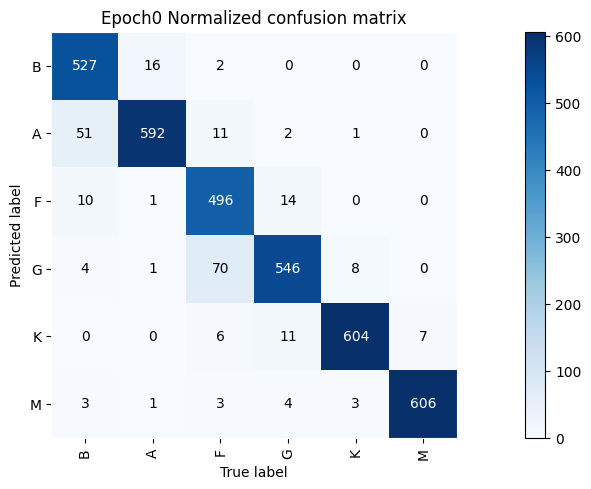

Precision of  B : 96.70 %,Recall : 88.57 %,F1 value : 92.46 %,F2 : 90.09 % 
Precision of  A : 90.11 %,Recall : 96.89 %,F1 value : 93.38 %,F2 : 95.45 % 
Precision of  F : 95.20 %,Recall : 84.35 %,F1 value : 89.45 %,F2 : 86.32 % 
Precision of  G : 86.80 %,Recall : 94.63 %,F1 value : 90.55 %,F2 : 92.95 % 
Precision of  K : 96.18 %,Recall : 98.05 %,F1 value : 97.11 %,F2 : 97.67 % 
Precision of  M : 97.74 %,Recall : 98.86 %,F1 value : 98.30 %,F2 : 98.63 % 
Epoch  1/30
train_time: 2.945957899093628
44.04741960763931
tensor(94.8056, device='cuda:8')
test_time: 0.32407355308532715
TR_Loss is :0.014178,TE_Loss is 0.012235,Train Accuracy is:91.6786%,Test Accuracy is:94.8056%
tensor([[557.,  36.,   5.,   0.,   0.,   0.],
        [ 25., 572.,   9.,   2.,   0.,   0.],
        [  7.,   1., 531.,  27.,   1.,   0.],
        [  4.,   1.,  38., 537.,   5.,   0.],
        [  0.,   0.,   3.,   8., 608.,   5.],
        [  2.,   1.,   2.,   3.,   2., 608.]])
means:-0.010
std:0.318
Confusion matrix, without 

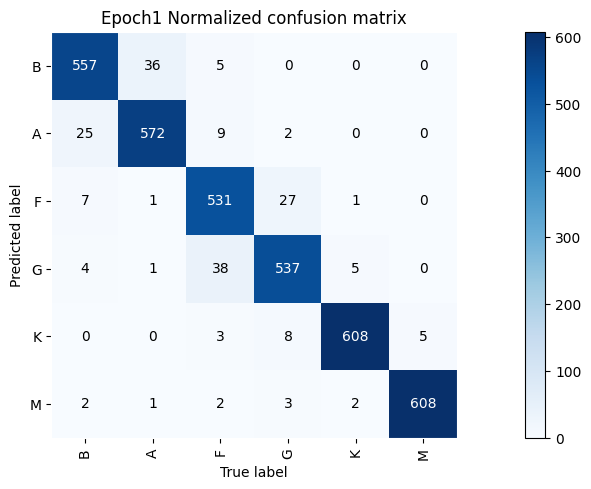

Precision of  B : 93.14 %,Recall : 93.61 %,F1 value : 93.38 %,F2 : 93.52 % 
Precision of  A : 94.08 %,Recall : 93.62 %,F1 value : 93.85 %,F2 : 93.71 % 
Precision of  F : 93.65 %,Recall : 90.31 %,F1 value : 91.95 %,F2 : 90.96 % 
Precision of  G : 91.79 %,Recall : 93.07 %,F1 value : 92.43 %,F2 : 92.81 % 
Precision of  K : 97.44 %,Recall : 98.70 %,F1 value : 98.06 %,F2 : 98.45 % 
Precision of  M : 98.38 %,Recall : 99.18 %,F1 value : 98.78 %,F2 : 99.02 % 
Epoch  2/30
train_time: 2.95186710357666
42.30055731534958
tensor(95.1111, device='cuda:8')
test_time: 0.32068896293640137
TR_Loss is :0.013255,TE_Loss is 0.011750,Train Accuracy is:92.8214%,Test Accuracy is:95.1111%
tensor([[549.,  17.,   4.,   0.,   0.,   0.],
        [ 33., 592.,   8.,   1.,   0.,   0.],
        [  7.,   0., 528.,  30.,   1.,   0.],
        [  5.,   1.,  45., 540.,   6.,   1.],
        [  0.,   0.,   2.,   4., 608.,   5.],
        [  1.,   1.,   1.,   2.,   1., 607.]])
means:-0.015
std:0.298
Confusion matrix, without n

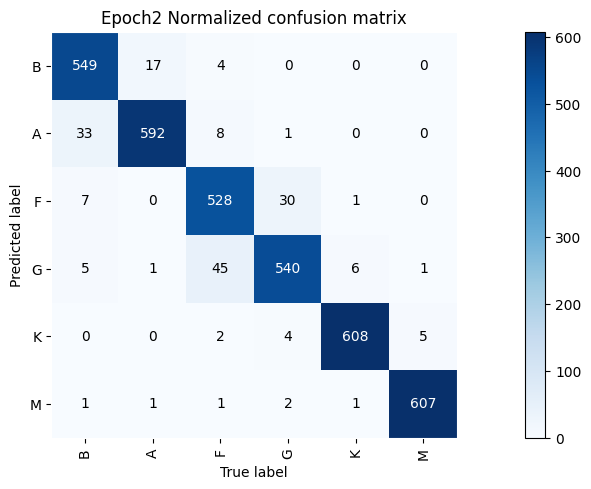

Precision of  B : 96.32 %,Recall : 92.27 %,F1 value : 94.25 %,F2 : 93.05 % 
Precision of  A : 93.38 %,Recall : 96.89 %,F1 value : 95.10 %,F2 : 96.17 % 
Precision of  F : 93.29 %,Recall : 89.80 %,F1 value : 91.51 %,F2 : 90.47 % 
Precision of  G : 90.30 %,Recall : 93.59 %,F1 value : 91.91 %,F2 : 92.91 % 
Precision of  K : 98.22 %,Recall : 98.70 %,F1 value : 98.46 %,F2 : 98.61 % 
Precision of  M : 99.02 %,Recall : 99.02 %,F1 value : 99.02 %,F2 : 99.02 % 
Epoch  3/30
train_time: 2.951068162918091
41.17783313989639
tensor(95.2222, device='cuda:8')
test_time: 0.3191030025482178
TR_Loss is :0.012621,TE_Loss is 0.011438,Train Accuracy is:94.2381%,Test Accuracy is:95.2222%
tensor([[535.,   9.,   2.,   0.,   0.,   0.],
        [ 47., 600.,   7.,   1.,   0.,   0.],
        [  6.,   0., 539.,  31.,   2.,   0.],
        [  6.,   1.,  38., 541.,   8.,   1.],
        [  0.,   0.,   1.,   2., 605.,   4.],
        [  1.,   1.,   1.,   2.,   1., 608.]])
means:-0.019
std:0.295
Confusion matrix, without n

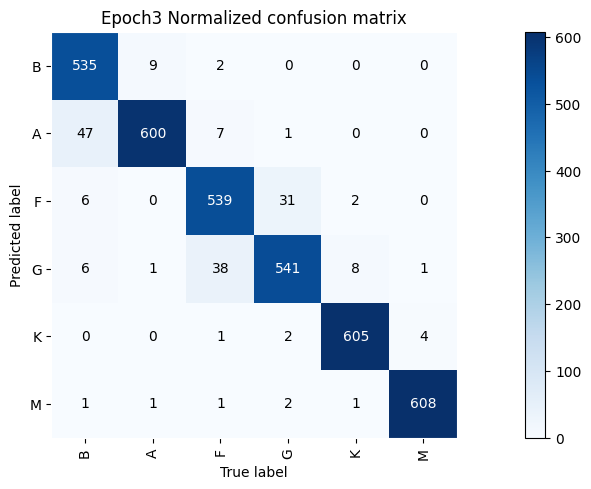

Precision of  B : 97.99 %,Recall : 89.92 %,F1 value : 93.78 %,F2 : 91.42 % 
Precision of  A : 91.60 %,Recall : 98.20 %,F1 value : 94.79 %,F2 : 96.81 % 
Precision of  F : 93.25 %,Recall : 91.67 %,F1 value : 92.45 %,F2 : 91.98 % 
Precision of  G : 90.92 %,Recall : 93.76 %,F1 value : 92.32 %,F2 : 93.18 % 
Precision of  K : 98.86 %,Recall : 98.21 %,F1 value : 98.53 %,F2 : 98.34 % 
Precision of  M : 99.02 %,Recall : 99.18 %,F1 value : 99.10 %,F2 : 99.15 % 
Epoch  4/30
train_time: 2.935147523880005
41.401459604501724
tensor(95.6389, device='cuda:8')
test_time: 0.3168630599975586
TR_Loss is :0.012195,TE_Loss is 0.011500,Train Accuracy is:94.4881%,Test Accuracy is:95.6389%
tensor([[567.,  29.,   2.,   0.,   0.,   0.],
        [ 16., 579.,   6.,   1.,   0.,   0.],
        [  8.,   2., 560.,  54.,   3.,   0.],
        [  3.,   0.,  18., 518.,   4.,   0.],
        [  0.,   0.,   1.,   3., 609.,   3.],
        [  1.,   1.,   1.,   1.,   0., 610.]])
means:0.008
std:0.277
Confusion matrix, without n

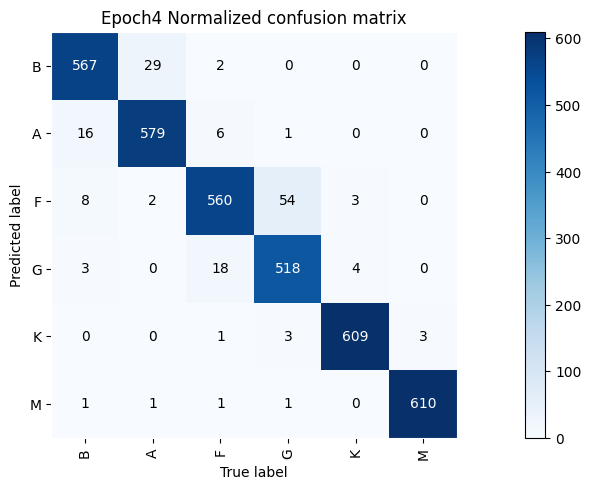

Precision of  B : 94.82 %,Recall : 95.29 %,F1 value : 95.05 %,F2 : 95.20 % 
Precision of  A : 96.18 %,Recall : 94.76 %,F1 value : 95.47 %,F2 : 95.04 % 
Precision of  F : 89.31 %,Recall : 95.24 %,F1 value : 92.18 %,F2 : 93.99 % 
Precision of  G : 95.40 %,Recall : 89.77 %,F1 value : 92.50 %,F2 : 90.85 % 
Precision of  K : 98.86 %,Recall : 98.86 %,F1 value : 98.86 %,F2 : 98.86 % 
Precision of  M : 99.35 %,Recall : 99.51 %,F1 value : 99.43 %,F2 : 99.48 % 
Epoch  5/30
train_time: 2.9303314685821533
40.80009552836418
tensor(95.6945, device='cuda:8')
test_time: 0.32295894622802734
TR_Loss is :0.011676,TE_Loss is 0.011333,Train Accuracy is:95.2500%,Test Accuracy is:95.6944%
tensor([[571.,  39.,   3.,   0.,   0.,   0.],
        [ 14., 571.,   3.,   1.,   0.,   0.],
        [  5.,   0., 549.,  37.,   1.,   0.],
        [  4.,   0.,  31., 536.,   6.,   1.],
        [  0.,   0.,   1.,   2., 609.,   3.],
        [  1.,   1.,   1.,   1.,   0., 609.]])
means:0.004
std:0.275
Confusion matrix, without 

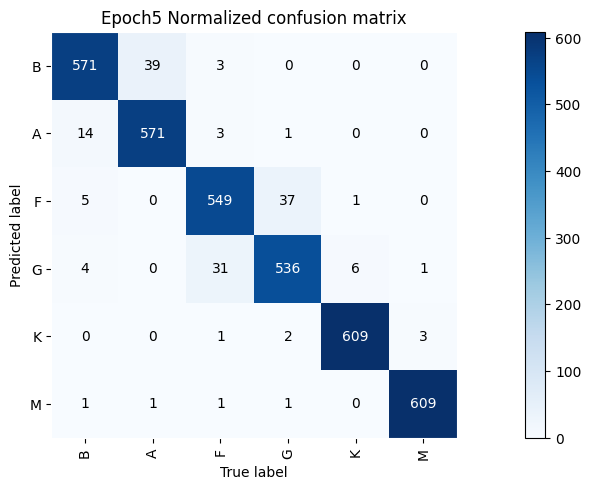

Precision of  B : 93.15 %,Recall : 95.97 %,F1 value : 94.54 %,F2 : 95.39 % 
Precision of  A : 96.94 %,Recall : 93.45 %,F1 value : 95.17 %,F2 : 94.13 % 
Precision of  F : 92.74 %,Recall : 93.37 %,F1 value : 93.05 %,F2 : 93.24 % 
Precision of  G : 92.73 %,Recall : 92.89 %,F1 value : 92.81 %,F2 : 92.86 % 
Precision of  K : 99.02 %,Recall : 98.86 %,F1 value : 98.94 %,F2 : 98.90 % 
Precision of  M : 99.35 %,Recall : 99.35 %,F1 value : 99.35 %,F2 : 99.35 % 
Epoch  6/30
train_time: 2.9290223121643066
40.051805198192596
tensor(95.3056, device='cuda:8')
test_time: 0.317737340927124
TR_Loss is :0.011421,TE_Loss is 0.011126,Train Accuracy is:95.5952%,Test Accuracy is:95.3056%
tensor([[545.,   9.,   4.,   0.,   0.,   0.],
        [ 40., 600.,   5.,   1.,   0.,   0.],
        [  6.,   0., 514.,  19.,   1.,   0.],
        [  4.,   1.,  63., 553.,   5.,   1.],
        [  0.,   0.,   1.,   3., 610.,   3.],
        [  0.,   1.,   1.,   1.,   0., 609.]])
means:-0.024
std:0.274
Confusion matrix, without 

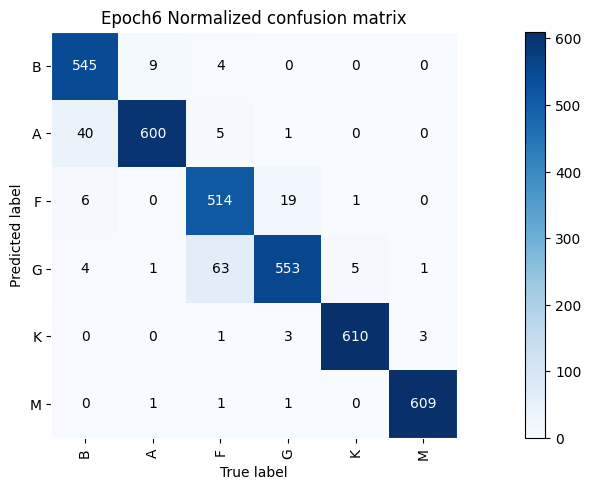

Precision of  B : 97.67 %,Recall : 91.60 %,F1 value : 94.54 %,F2 : 92.75 % 
Precision of  A : 92.88 %,Recall : 98.20 %,F1 value : 95.47 %,F2 : 97.09 % 
Precision of  F : 95.19 %,Recall : 87.41 %,F1 value : 91.13 %,F2 : 88.87 % 
Precision of  G : 88.20 %,Recall : 95.84 %,F1 value : 91.86 %,F2 : 94.21 % 
Precision of  K : 98.87 %,Recall : 99.03 %,F1 value : 98.95 %,F2 : 98.99 % 
Precision of  M : 99.51 %,Recall : 99.35 %,F1 value : 99.43 %,F2 : 99.38 % 
Epoch  7/30
train_time: 2.9329986572265625
39.46918961405754
tensor(95.8889, device='cuda:8')
test_time: 0.316514253616333
TR_Loss is :0.011242,TE_Loss is 0.010964,Train Accuracy is:96.0000%,Test Accuracy is:95.8889%
tensor([[549.,   9.,   4.,   0.,   0.,   0.],
        [ 37., 601.,   4.,   1.,   0.,   0.],
        [  5.,   0., 529.,  22.,   0.,   0.],
        [  4.,   0.,  49., 552.,   4.,   1.],
        [  0.,   0.,   1.,   1., 612.,   3.],
        [  0.,   1.,   1.,   1.,   0., 609.]])
means:-0.018
std:0.259
Confusion matrix, without n

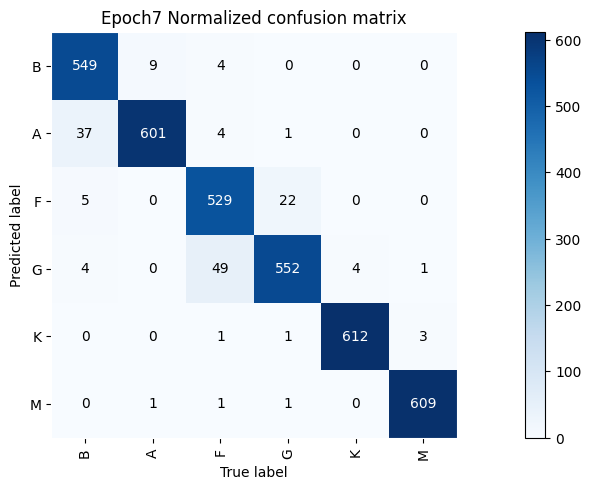

Precision of  B : 97.69 %,Recall : 92.27 %,F1 value : 94.90 %,F2 : 93.30 % 
Precision of  A : 93.47 %,Recall : 98.36 %,F1 value : 95.85 %,F2 : 97.34 % 
Precision of  F : 95.14 %,Recall : 89.97 %,F1 value : 92.48 %,F2 : 90.96 % 
Precision of  G : 90.49 %,Recall : 95.67 %,F1 value : 93.01 %,F2 : 94.59 % 
Precision of  K : 99.19 %,Recall : 99.35 %,F1 value : 99.27 %,F2 : 99.32 % 
Precision of  M : 99.51 %,Recall : 99.35 %,F1 value : 99.43 %,F2 : 99.38 % 
Epoch  8/30
train_time: 2.93912410736084
39.10931923985481
tensor(96.2778, device='cuda:8')
test_time: 0.3325388431549072
TR_Loss is :0.011168,TE_Loss is 0.010864,Train Accuracy is:96.0119%,Test Accuracy is:96.2778%
tensor([[558.,  12.,   4.,   1.,   0.,   0.],
        [ 28., 598.,   4.,   1.,   0.,   0.],
        [  5.,   0., 540.,  24.,   0.,   0.],
        [  4.,   0.,  38., 549.,   4.,   1.],
        [  0.,   0.,   1.,   2., 612.,   3.],
        [  0.,   1.,   1.,   0.,   0., 609.]])
means:-0.010
std:0.254
Confusion matrix, without no

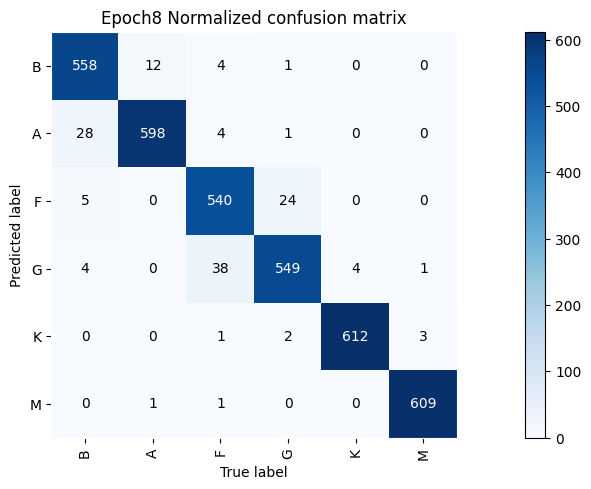

Precision of  B : 97.04 %,Recall : 93.78 %,F1 value : 95.38 %,F2 : 94.42 % 
Precision of  A : 94.77 %,Recall : 97.87 %,F1 value : 96.30 %,F2 : 97.24 % 
Precision of  F : 94.90 %,Recall : 91.84 %,F1 value : 93.34 %,F2 : 92.43 % 
Precision of  G : 92.11 %,Recall : 95.15 %,F1 value : 93.61 %,F2 : 94.52 % 
Precision of  K : 99.03 %,Recall : 99.35 %,F1 value : 99.19 %,F2 : 99.29 % 
Precision of  M : 99.67 %,Recall : 99.35 %,F1 value : 99.51 %,F2 : 99.41 % 
Epoch  9/30
train_time: 2.940647840499878
38.93109288811684
tensor(96.2222, device='cuda:8')
test_time: 0.31852006912231445
TR_Loss is :0.011038,TE_Loss is 0.010814,Train Accuracy is:96.3095%,Test Accuracy is:96.2222%
tensor([[559.,  12.,   4.,   1.,   0.,   0.],
        [ 25., 598.,   4.,   1.,   0.,   0.],
        [  7.,   0., 546.,  31.,   1.,   0.],
        [  4.,   0.,  32., 540.,   4.,   1.],
        [  0.,   0.,   1.,   3., 611.,   2.],
        [  0.,   1.,   1.,   1.,   0., 610.]])
means:-0.007
std:0.262
Confusion matrix, without 

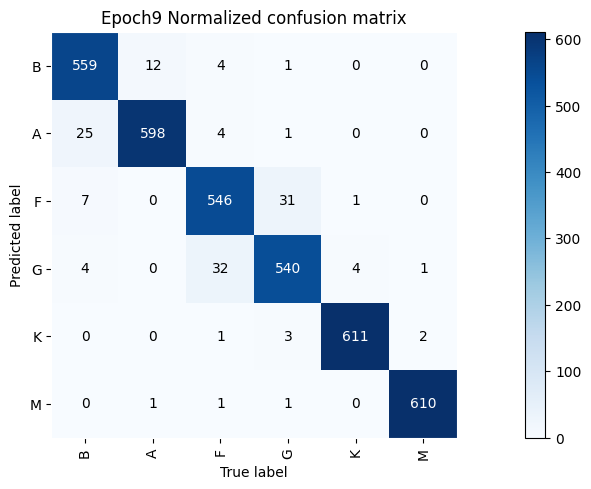

Precision of  B : 97.05 %,Recall : 93.95 %,F1 value : 95.47 %,F2 : 94.55 % 
Precision of  A : 95.22 %,Recall : 97.87 %,F1 value : 96.53 %,F2 : 97.33 % 
Precision of  F : 93.33 %,Recall : 92.86 %,F1 value : 93.09 %,F2 : 92.95 % 
Precision of  G : 92.94 %,Recall : 93.59 %,F1 value : 93.26 %,F2 : 93.46 % 
Precision of  K : 99.03 %,Recall : 99.19 %,F1 value : 99.11 %,F2 : 99.16 % 
Precision of  M : 99.51 %,Recall : 99.51 %,F1 value : 99.51 %,F2 : 99.51 % 
Epoch  10/30
train_time: 2.937680244445801
38.82889297604561
tensor(96.2500, device='cuda:8')
test_time: 0.32225656509399414
TR_Loss is :0.010842,TE_Loss is 0.010786,Train Accuracy is:96.5952%,Test Accuracy is:96.2500%
tensor([[546.,   6.,   3.,   1.,   0.,   0.],
        [ 39., 604.,   4.,   1.,   0.,   0.],
        [  6.,   0., 545.,  24.,   1.,   0.],
        [  4.,   0.,  34., 549.,   4.,   1.],
        [  0.,   0.,   1.,   1., 611.,   2.],
        [  0.,   1.,   1.,   1.,   0., 610.]])
means:-0.015
std:0.258
Confusion matrix, without

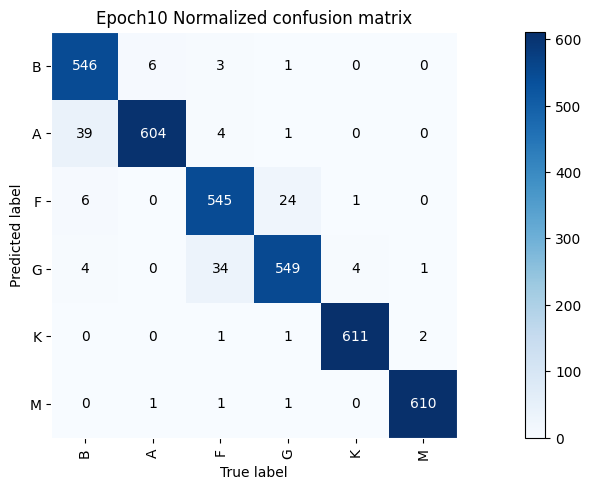

Precision of  B : 98.20 %,Recall : 91.76 %,F1 value : 94.87 %,F2 : 92.98 % 
Precision of  A : 93.21 %,Recall : 98.85 %,F1 value : 95.95 %,F2 : 97.67 % 
Precision of  F : 94.62 %,Recall : 92.69 %,F1 value : 93.64 %,F2 : 93.07 % 
Precision of  G : 92.74 %,Recall : 95.15 %,F1 value : 93.93 %,F2 : 94.66 % 
Precision of  K : 99.35 %,Recall : 99.19 %,F1 value : 99.27 %,F2 : 99.22 % 
Precision of  M : 99.51 %,Recall : 99.51 %,F1 value : 99.51 %,F2 : 99.51 % 
Epoch  11/30
train_time: 2.950277328491211
38.7618328332901
tensor(96.3333, device='cuda:8')
test_time: 0.32067084312438965
TR_Loss is :0.010781,TE_Loss is 0.010767,Train Accuracy is:96.7381%,Test Accuracy is:96.3333%
tensor([[564.,  15.,   4.,   1.,   0.,   0.],
        [ 21., 594.,   2.,   1.,   0.,   0.],
        [  6.,   0., 544.,  26.,   0.,   0.],
        [  4.,   1.,  35., 545.,   4.,   1.],
        [  0.,   0.,   2.,   3., 612.,   3.],
        [  0.,   1.,   1.,   1.,   0., 609.]])
means:-0.009
std:0.260
Confusion matrix, without 

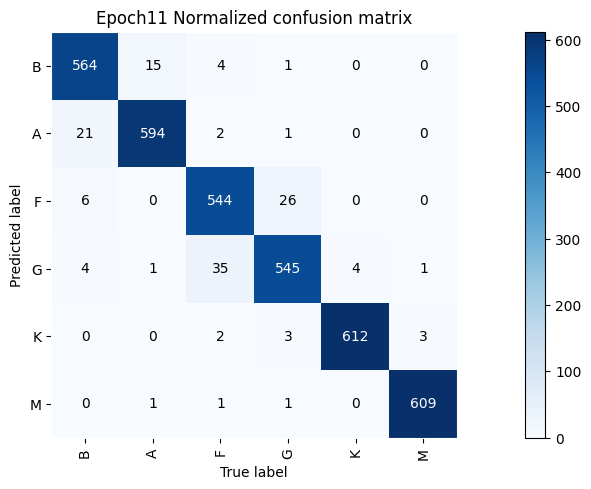

Precision of  B : 96.58 %,Recall : 94.79 %,F1 value : 95.67 %,F2 : 95.14 % 
Precision of  A : 96.12 %,Recall : 97.22 %,F1 value : 96.66 %,F2 : 97.00 % 
Precision of  F : 94.44 %,Recall : 92.52 %,F1 value : 93.47 %,F2 : 92.90 % 
Precision of  G : 92.37 %,Recall : 94.45 %,F1 value : 93.40 %,F2 : 94.03 % 
Precision of  K : 98.71 %,Recall : 99.35 %,F1 value : 99.03 %,F2 : 99.22 % 
Precision of  M : 99.51 %,Recall : 99.35 %,F1 value : 99.43 %,F2 : 99.38 % 
Epoch  12/30
train_time: 2.9389772415161133
38.75967875123024
tensor(96.1111, device='cuda:8')
test_time: 0.31978702545166016
TR_Loss is :0.010650,TE_Loss is 0.010767,Train Accuracy is:96.8690%,Test Accuracy is:96.1111%
tensor([[546.,   9.,   4.,   1.,   0.,   0.],
        [ 39., 601.,   4.,   1.,   0.,   0.],
        [  6.,   0., 542.,  23.,   1.,   0.],
        [  4.,   0.,  36., 551.,   5.,   1.],
        [  0.,   0.,   1.,   1., 610.,   2.],
        [  0.,   1.,   1.,   0.,   0., 610.]])
means:-0.014
std:0.261
Confusion matrix, withou

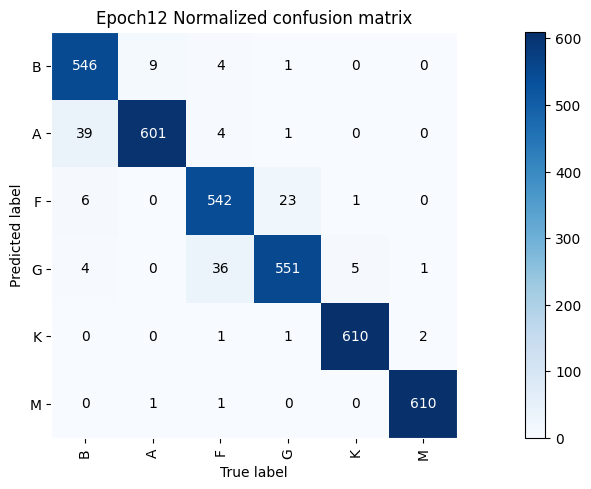

Precision of  B : 97.50 %,Recall : 91.76 %,F1 value : 94.55 %,F2 : 92.86 % 
Precision of  A : 93.18 %,Recall : 98.36 %,F1 value : 95.70 %,F2 : 97.28 % 
Precision of  F : 94.76 %,Recall : 92.18 %,F1 value : 93.45 %,F2 : 92.68 % 
Precision of  G : 92.29 %,Recall : 95.49 %,F1 value : 93.87 %,F2 : 94.84 % 
Precision of  K : 99.35 %,Recall : 99.03 %,F1 value : 99.19 %,F2 : 99.09 % 
Precision of  M : 99.67 %,Recall : 99.51 %,F1 value : 99.59 %,F2 : 99.54 % 
Epoch  13/30
train_time: 2.941713809967041
38.64453837275505
tensor(96.3611, device='cuda:8')
test_time: 0.319291353225708
TR_Loss is :0.010622,TE_Loss is 0.010735,Train Accuracy is:96.7976%,Test Accuracy is:96.3611%
tensor([[562.,  13.,   4.,   1.,   0.,   0.],
        [ 24., 597.,   3.,   1.,   0.,   0.],
        [  5.,   0., 536.,  22.,   0.,   0.],
        [  4.,   0.,  43., 552.,   4.,   1.],
        [  0.,   0.,   1.,   1., 612.,   2.],
        [  0.,   1.,   1.,   0.,   0., 610.]])
means:-0.011
std:0.253
Confusion matrix, without n

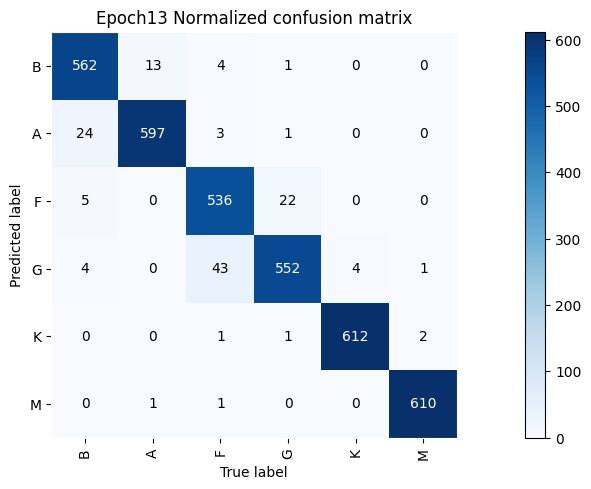

Precision of  B : 96.90 %,Recall : 94.45 %,F1 value : 95.66 %,F2 : 94.93 % 
Precision of  A : 95.52 %,Recall : 97.71 %,F1 value : 96.60 %,F2 : 97.26 % 
Precision of  F : 95.20 %,Recall : 91.16 %,F1 value : 93.14 %,F2 : 91.94 % 
Precision of  G : 91.39 %,Recall : 95.67 %,F1 value : 93.48 %,F2 : 94.78 % 
Precision of  K : 99.35 %,Recall : 99.35 %,F1 value : 99.35 %,F2 : 99.35 % 
Precision of  M : 99.67 %,Recall : 99.51 %,F1 value : 99.59 %,F2 : 99.54 % 
Epoch  14/30
train_time: 2.9356513023376465
38.90697559714317
tensor(96.1389, device='cuda:8')
test_time: 0.3167862892150879
TR_Loss is :0.010573,TE_Loss is 0.010807,Train Accuracy is:96.7143%,Test Accuracy is:96.1389%
tensor([[568.,  24.,   4.,   1.,   0.,   0.],
        [ 17., 585.,   2.,   1.,   0.,   0.],
        [  6.,   0., 531.,  19.,   0.,   0.],
        [  4.,   1.,  49., 555.,   5.,   1.],
        [  0.,   0.,   1.,   1., 611.,   1.],
        [  0.,   1.,   1.,   0.,   0., 611.]])
means:-0.010
std:0.260
Confusion matrix, without

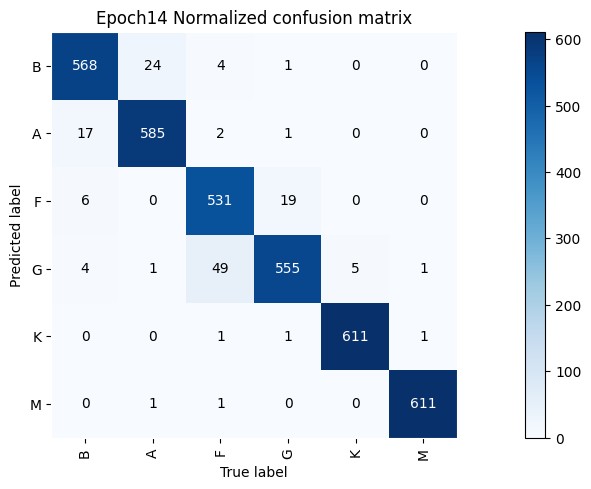

Precision of  B : 95.14 %,Recall : 95.46 %,F1 value : 95.30 %,F2 : 95.40 % 
Precision of  A : 96.69 %,Recall : 95.74 %,F1 value : 96.22 %,F2 : 95.93 % 
Precision of  F : 95.50 %,Recall : 90.31 %,F1 value : 92.83 %,F2 : 91.30 % 
Precision of  G : 90.24 %,Recall : 96.19 %,F1 value : 93.12 %,F2 : 94.94 % 
Precision of  K : 99.51 %,Recall : 99.19 %,F1 value : 99.35 %,F2 : 99.25 % 
Precision of  M : 99.67 %,Recall : 99.67 %,F1 value : 99.67 %,F2 : 99.67 % 
Epoch  15/30
train_time: 2.9360427856445312
38.59362456202507
tensor(96.3889, device='cuda:8')
test_time: 0.32274866104125977
TR_Loss is :0.010495,TE_Loss is 0.010720,Train Accuracy is:97.1548%,Test Accuracy is:96.3889%
tensor([[552.,   9.,   4.,   1.,   0.,   0.],
        [ 33., 601.,   2.,   1.,   0.,   0.],
        [  6.,   0., 544.,  23.,   0.,   0.],
        [  4.,   0.,  36., 551.,   4.,   1.],
        [  0.,   0.,   1.,   1., 612.,   2.],
        [  0.,   1.,   1.,   0.,   0., 610.]])
means:-0.013
std:0.254
Confusion matrix, withou

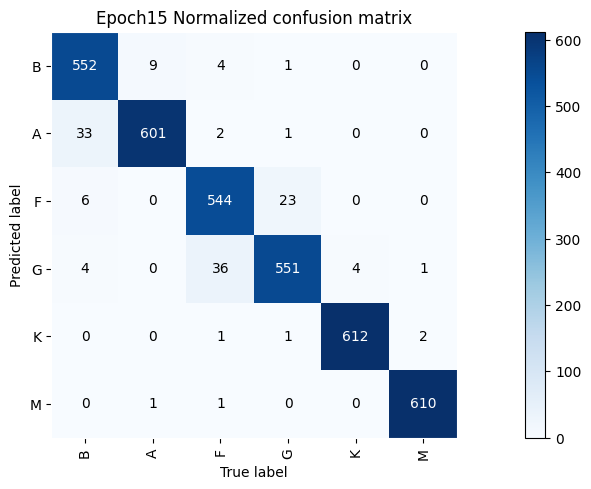

Precision of  B : 97.53 %,Recall : 92.77 %,F1 value : 95.09 %,F2 : 93.69 % 
Precision of  A : 94.35 %,Recall : 98.36 %,F1 value : 96.31 %,F2 : 97.53 % 
Precision of  F : 94.94 %,Recall : 92.52 %,F1 value : 93.71 %,F2 : 92.99 % 
Precision of  G : 92.45 %,Recall : 95.49 %,F1 value : 93.95 %,F2 : 94.87 % 
Precision of  K : 99.35 %,Recall : 99.35 %,F1 value : 99.35 %,F2 : 99.35 % 
Precision of  M : 99.67 %,Recall : 99.51 %,F1 value : 99.59 %,F2 : 99.54 % 
Epoch  16/30
train_time: 2.932490587234497
38.4598243534565
tensor(96.2222, device='cuda:8')
test_time: 0.3241438865661621
TR_Loss is :0.010470,TE_Loss is 0.010683,Train Accuracy is:96.9286%,Test Accuracy is:96.2222%
tensor([[561.,  14.,   4.,   1.,   0.,   0.],
        [ 24., 595.,   2.,   1.,   0.,   0.],
        [  6.,   0., 529.,  17.,   0.,   0.],
        [  4.,   1.,  51., 557.,   4.,   1.],
        [  0.,   0.,   1.,   1., 612.,   2.],
        [  0.,   1.,   1.,   0.,   0., 610.]])
means:-0.016
std:0.258
Confusion matrix, without n

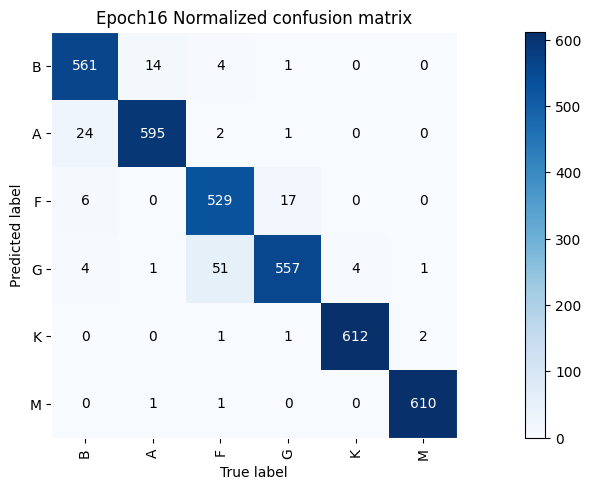

Precision of  B : 96.72 %,Recall : 94.29 %,F1 value : 95.49 %,F2 : 94.76 % 
Precision of  A : 95.66 %,Recall : 97.38 %,F1 value : 96.51 %,F2 : 97.03 % 
Precision of  F : 95.83 %,Recall : 89.97 %,F1 value : 92.81 %,F2 : 91.08 % 
Precision of  G : 90.13 %,Recall : 96.53 %,F1 value : 93.22 %,F2 : 95.18 % 
Precision of  K : 99.35 %,Recall : 99.35 %,F1 value : 99.35 %,F2 : 99.35 % 
Precision of  M : 99.67 %,Recall : 99.51 %,F1 value : 99.59 %,F2 : 99.54 % 
Epoch  17/30
train_time: 2.94830322265625
38.256204038858414
tensor(96.6945, device='cuda:8')
test_time: 0.3139770030975342
TR_Loss is :0.010407,TE_Loss is 0.010627,Train Accuracy is:97.1667%,Test Accuracy is:96.6944%
tensor([[561.,  14.,   4.,   1.,   0.,   0.],
        [ 24., 596.,   2.,   1.,   0.,   0.],
        [  6.,   0., 553.,  24.,   1.,   0.],
        [  4.,   0.,  27., 550.,   4.,   1.],
        [  0.,   0.,   1.,   1., 611.,   2.],
        [  0.,   1.,   1.,   0.,   0., 610.]])
means:-0.006
std:0.249
Confusion matrix, without 

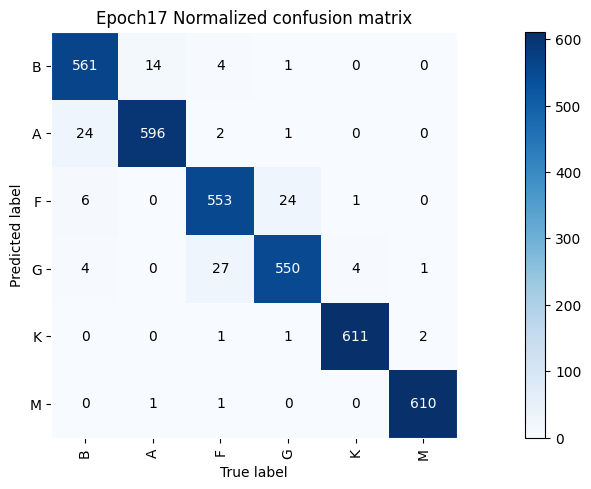

Precision of  B : 96.72 %,Recall : 94.29 %,F1 value : 95.49 %,F2 : 94.76 % 
Precision of  A : 95.67 %,Recall : 97.55 %,F1 value : 96.60 %,F2 : 97.16 % 
Precision of  F : 94.69 %,Recall : 94.05 %,F1 value : 94.37 %,F2 : 94.18 % 
Precision of  G : 93.86 %,Recall : 95.32 %,F1 value : 94.58 %,F2 : 95.02 % 
Precision of  K : 99.35 %,Recall : 99.19 %,F1 value : 99.27 %,F2 : 99.22 % 
Precision of  M : 99.67 %,Recall : 99.51 %,F1 value : 99.59 %,F2 : 99.54 % 
Epoch  18/30
train_time: 2.931166410446167
38.234622567892075
tensor(96.5278, device='cuda:8')
test_time: 0.3221292495727539
TR_Loss is :0.010442,TE_Loss is 0.010621,Train Accuracy is:96.9405%,Test Accuracy is:96.5278%
tensor([[561.,  14.,   4.,   1.,   0.,   0.],
        [ 24., 596.,   2.,   1.,   0.,   0.],
        [  6.,   0., 544.,  22.,   0.,   0.],
        [  4.,   0.,  36., 552.,   4.,   1.],
        [  0.,   0.,   1.,   1., 612.,   2.],
        [  0.,   1.,   1.,   0.,   0., 610.]])
means:-0.010
std:0.251
Confusion matrix, without

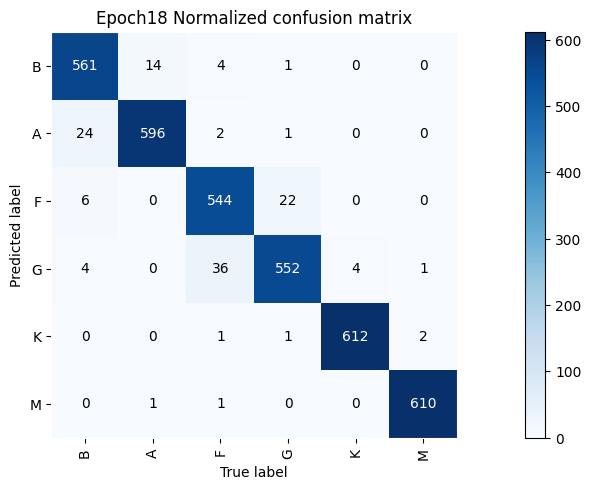

Precision of  B : 96.72 %,Recall : 94.29 %,F1 value : 95.49 %,F2 : 94.76 % 
Precision of  A : 95.67 %,Recall : 97.55 %,F1 value : 96.60 %,F2 : 97.16 % 
Precision of  F : 95.10 %,Recall : 92.52 %,F1 value : 93.79 %,F2 : 93.02 % 
Precision of  G : 92.46 %,Recall : 95.67 %,F1 value : 94.04 %,F2 : 95.01 % 
Precision of  K : 99.35 %,Recall : 99.35 %,F1 value : 99.35 %,F2 : 99.35 % 
Precision of  M : 99.67 %,Recall : 99.51 %,F1 value : 99.59 %,F2 : 99.54 % 
Epoch  19/30
train_time: 2.954270124435425
38.234029561281204
tensor(96.5833, device='cuda:8')
test_time: 0.32858729362487793
TR_Loss is :0.010336,TE_Loss is 0.010621,Train Accuracy is:97.2619%,Test Accuracy is:96.5833%
tensor([[559.,  12.,   4.,   1.,   0.,   0.],
        [ 26., 598.,   2.,   1.,   0.,   0.],
        [  6.,   0., 549.,  24.,   0.,   0.],
        [  4.,   0.,  31., 549.,   4.,   1.],
        [  0.,   0.,   1.,   1., 612.,   2.],
        [  0.,   1.,   1.,   1.,   0., 610.]])
means:-0.009
std:0.251
Confusion matrix, withou

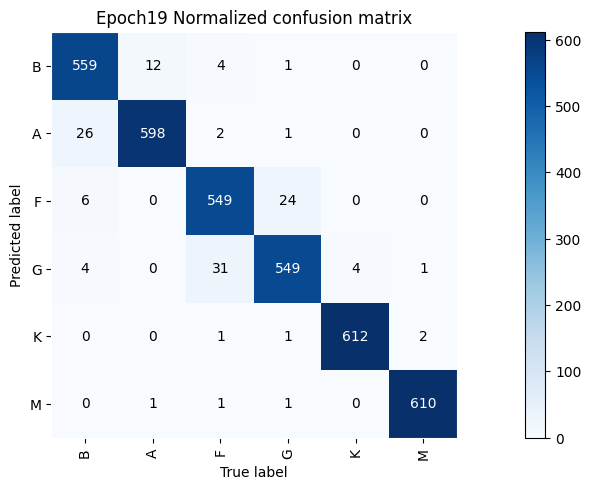

Precision of  B : 97.05 %,Recall : 93.95 %,F1 value : 95.47 %,F2 : 94.55 % 
Precision of  A : 95.37 %,Recall : 97.87 %,F1 value : 96.61 %,F2 : 97.36 % 
Precision of  F : 94.82 %,Recall : 93.37 %,F1 value : 94.09 %,F2 : 93.65 % 
Precision of  G : 93.21 %,Recall : 95.15 %,F1 value : 94.17 %,F2 : 94.75 % 
Precision of  K : 99.35 %,Recall : 99.35 %,F1 value : 99.35 %,F2 : 99.35 % 
Precision of  M : 99.51 %,Recall : 99.51 %,F1 value : 99.51 %,F2 : 99.51 % 
Epoch  20/30
train_time: 3.028299570083618
38.20556491613388
tensor(96.5556, device='cuda:8')
test_time: 0.33022499084472656
TR_Loss is :0.010275,TE_Loss is 0.010613,Train Accuracy is:97.3690%,Test Accuracy is:96.5556%
tensor([[562.,  14.,   4.,   1.,   0.,   0.],
        [ 23., 596.,   2.,   1.,   0.,   0.],
        [  6.,   0., 545.,  23.,   0.,   0.],
        [  4.,   0.,  35., 551.,   4.,   1.],
        [  0.,   0.,   1.,   1., 612.,   2.],
        [  0.,   1.,   1.,   0.,   0., 610.]])
means:-0.009
std:0.250
Confusion matrix, without

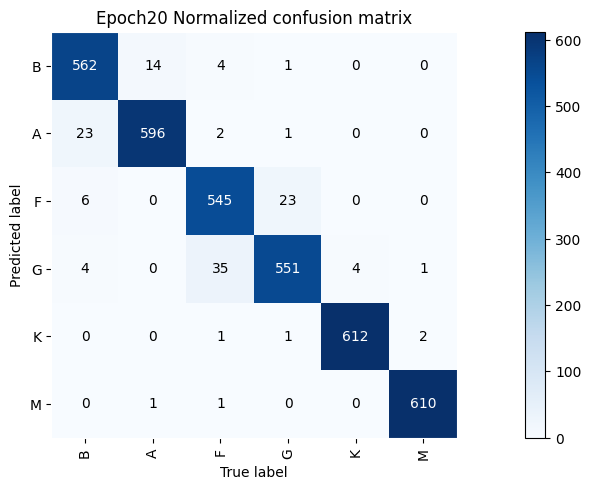

Precision of  B : 96.73 %,Recall : 94.45 %,F1 value : 95.58 %,F2 : 94.90 % 
Precision of  A : 95.82 %,Recall : 97.55 %,F1 value : 96.67 %,F2 : 97.20 % 
Precision of  F : 94.95 %,Recall : 92.69 %,F1 value : 93.80 %,F2 : 93.13 % 
Precision of  G : 92.61 %,Recall : 95.49 %,F1 value : 94.03 %,F2 : 94.90 % 
Precision of  K : 99.35 %,Recall : 99.35 %,F1 value : 99.35 %,F2 : 99.35 % 
Precision of  M : 99.67 %,Recall : 99.51 %,F1 value : 99.59 %,F2 : 99.54 % 
Epoch  21/30
train_time: 2.9983277320861816
38.24487030506134
tensor(96.6111, device='cuda:8')
test_time: 0.3252384662628174
TR_Loss is :0.010313,TE_Loss is 0.010624,Train Accuracy is:97.2619%,Test Accuracy is:96.6111%
tensor([[560.,  13.,   4.,   1.,   0.,   0.],
        [ 25., 597.,   2.,   1.,   0.,   0.],
        [  6.,   0., 549.,  24.,   0.,   0.],
        [  4.,   0.,  31., 550.,   4.,   1.],
        [  0.,   0.,   1.,   1., 612.,   2.],
        [  0.,   1.,   1.,   0.,   0., 610.]])
means:-0.008
std:0.249
Confusion matrix, without

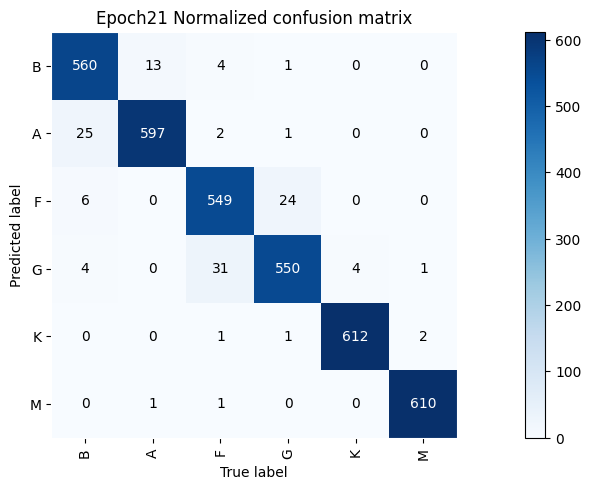

Precision of  B : 96.89 %,Recall : 94.12 %,F1 value : 95.48 %,F2 : 94.66 % 
Precision of  A : 95.52 %,Recall : 97.71 %,F1 value : 96.60 %,F2 : 97.26 % 
Precision of  F : 94.82 %,Recall : 93.37 %,F1 value : 94.09 %,F2 : 93.65 % 
Precision of  G : 93.22 %,Recall : 95.32 %,F1 value : 94.26 %,F2 : 94.89 % 
Precision of  K : 99.35 %,Recall : 99.35 %,F1 value : 99.35 %,F2 : 99.35 % 
Precision of  M : 99.67 %,Recall : 99.51 %,F1 value : 99.59 %,F2 : 99.54 % 
Epoch  22/30
train_time: 3.0460944175720215
38.16878145933151
tensor(96.4722, device='cuda:8')
test_time: 0.33887171745300293
TR_Loss is :0.010294,TE_Loss is 0.010602,Train Accuracy is:97.2262%,Test Accuracy is:96.4722%
tensor([[559.,  11.,   4.,   1.,   0.,   0.],
        [ 26., 599.,   2.,   1.,   0.,   0.],
        [  6.,   0., 541.,  22.,   0.,   0.],
        [  4.,   0.,  39., 552.,   4.,   1.],
        [  0.,   0.,   1.,   1., 612.,   2.],
        [  0.,   1.,   1.,   0.,   0., 610.]])
means:-0.012
std:0.252
Confusion matrix, withou

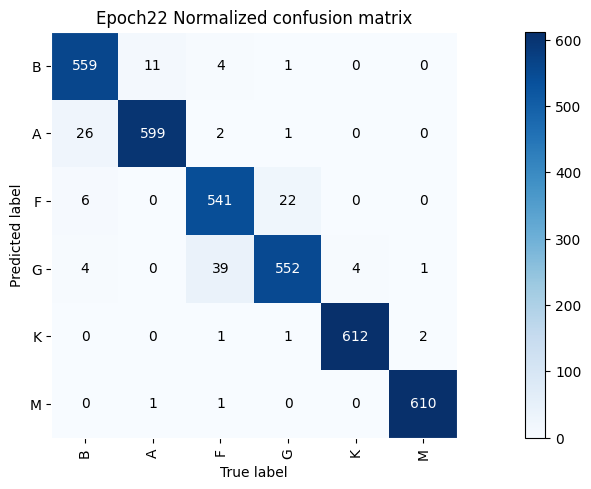

Precision of  B : 97.22 %,Recall : 93.95 %,F1 value : 95.56 %,F2 : 94.59 % 
Precision of  A : 95.38 %,Recall : 98.04 %,F1 value : 96.69 %,F2 : 97.49 % 
Precision of  F : 95.08 %,Recall : 92.01 %,F1 value : 93.52 %,F2 : 92.61 % 
Precision of  G : 92.00 %,Recall : 95.67 %,F1 value : 93.80 %,F2 : 94.91 % 
Precision of  K : 99.35 %,Recall : 99.35 %,F1 value : 99.35 %,F2 : 99.35 % 
Precision of  M : 99.67 %,Recall : 99.51 %,F1 value : 99.59 %,F2 : 99.54 % 
Epoch  23/30
train_time: 2.9991683959960938
38.16814252734184
tensor(96.5556, device='cuda:8')
test_time: 0.33219194412231445
TR_Loss is :0.010266,TE_Loss is 0.010602,Train Accuracy is:97.3095%,Test Accuracy is:96.5556%
Early stopping at epoch 23 with best Test Accuracy 96.6944%


In [11]:
# 第二版 CNN_Model（8 个卷积块）：
# - 已重命名为 CNN_Model_v8，不参与训练或调用；
# - 若将来需要恢复 8 层，只需把类名改回 CNN_Model 并在 run_CNN_module 中实例化即可。

class CNN_Model_v8(torch.nn.Module):
    def __init__(self):
        super(CNN_Model_v8, self).__init__()
        # 保持 1D 卷积风格：高为 1，沿谱线长度方向做卷积
        self.conv1 = torch.nn.Sequential(
            torch.nn.Conv2d(1, 10, kernel_size=(1, 2), stride=1),
            torch.nn.BatchNorm2d(10),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(stride=1, kernel_size=(1, 2)))  # 保持1D池化
        self.conv2 = torch.nn.Sequential(
            torch.nn.Conv2d(10, 20, kernel_size=(1, 3), stride=1),
            torch.nn.BatchNorm2d(20),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(stride=2, kernel_size=(1, 2)))
        self.conv3 = torch.nn.Sequential(
            torch.nn.Conv2d(20, 30, kernel_size=(1, 4), stride=1),
            torch.nn.BatchNorm2d(30),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(stride=1, kernel_size=(1, 2)))
        self.conv4 = torch.nn.Sequential(
            torch.nn.Conv2d(30, 40, kernel_size=(1, 5), stride=1),
            torch.nn.BatchNorm2d(40),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(stride=2, kernel_size=(1, 2)))
        self.conv5 = torch.nn.Sequential(  # 保留原conv5，删除重复定义
            torch.nn.Conv2d(40, 50, kernel_size=(1, 7), stride=1),
            torch.nn.BatchNorm2d(50),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(stride=2, kernel_size=(1, 2)))
        self.conv6 = torch.nn.Sequential(  # 保留原conv6，删除重复定义
            torch.nn.Conv2d(50, 60, kernel_size=(1, 9), stride=1),
            torch.nn.BatchNorm2d(60),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(stride=2, kernel_size=(1, 2)))
        self.conv7 = torch.nn.Sequential(
            torch.nn.Conv2d(60, 70, kernel_size=(1, 11), stride=1, padding=(0, 2)),  # 1D padding
            torch.nn.BatchNorm2d(70),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(stride=1, kernel_size=(1, 2)))
        self.conv8 = torch.nn.Sequential(  # 第8层卷积，补全8层结构
            torch.nn.Conv2d(70, 80, kernel_size=(1, 5), stride=1, padding=(0, 2)),
            torch.nn.BatchNorm2d(80),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(stride=2, kernel_size=(1, 2)))
        
        # 全连接层：按推算将卷积输出展平为 80*1*108，并映射到 1024 -> num_class
        self.dense = torch.nn.Sequential(
            torch.nn.ReLU(),
            torch.nn.Linear(80 * 1 * 108, 1024),  # 卷积输出展平后的维度
            torch.nn.ReLU(),
            # torch.nn.Dropout(p=0.5),  # 可选添加防止过拟合
            torch.nn.Linear(1024, num_class),
            torch.nn.Softmax(dim=1))  # 指定dim=1

    # 前向传播：依次通过 8 个卷积块，展平后进入全连接层得到最终类别概率
    def forward(self, x):
        x = self.conv1(x)
        # print('1:',x.shape)
        x = self.conv2(x)
        # print('2:',x.shape)
        x = self.conv3(x)
        # print('3:',x.shape)
        x = self.conv4(x)
        # print('4:',x.shape)
        x = self.conv5(x)
        # print('5:',x.shape)
        x = self.conv6(x)
        # print('6:',x.shape)
        x = self.conv7(x)
        # print('7:',x.shape)
        x = self.conv8(x)
        # print('8:',x.shape)
        # print("conv8输出shape:", x.shape)
        x = x.view(-1, 80 * 1 * 108) 
        # print("展平后shape:", x.shape)
        x = self.dense(x)
        # print("模型输出shape:", x.shape)
        
        return x

# 调用训练入口：将上面定义的超参数与数据加载器传入，开始训练与评估
run_CNN_module(device, num_class, num_epochs, batch_size, learning_rate, train, test, clsTR, clsTE)